# **Importing libraries and loading the dataset**

In [89]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE

In [90]:
data = pd.read_excel('Data_Cortex_Nuclear.xls', index_col='MouseID')
data = data.drop(['Genotype', 'Treatment', 'Behavior', 'class'], axis=1)
data = data.dropna()
data.head()

,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,pELK_N,...,SHH_N,BAD_N,BCL2_N,pS6_N,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N
MouseID,,,,,,,,,,,,,,,,,,,,,
3415_1,0.649781,0.828696,0.405862,2.921435,5.167979,0.207174,0.176640,3.728084,0.239283,1.666579,...,0.239752,0.139052,0.112926,0.132001,0.129363,0.486912,0.125152,0.146865,0.143517,1.627181
3415_2,0.616481,0.841974,0.388584,2.862575,5.194163,0.223433,0.167725,3.648240,0.221030,1.565150,...,0.249031,0.133787,0.121607,0.139008,0.143084,0.467833,0.112857,0.161132,0.145719,1.562096
3415_3,0.637424,0.852882,0.400561,2.968155,5.350820,0.208790,0.173261,3.814545,0.222300,1.741732,...,0.247956,0.142324,0.130261,0.134804,0.147673,0.462501,0.116433,0.160594,0.142879,1.571868
3415_4,0.576815,0.755390,0.348346,2.624901,4.727509,0.205892,0.161192,3.778530,0.194153,1.505475,...,0.233225,0.133637,0.107321,0.118982,0.121290,0.479110,0.102831,0.144238,0.141681,1.646608
3415_5,0.542545,0.757917,0.350051,2.634509,4.735602,0.210526,0.165671,3.871971,0.194297,1.531613,...,0.244469,0.133358,0.112851,0.128635,0.142617,0.438354,0.110614,0.155667,0.146408,1.607631


In [91]:
data.info()

<class 'pandas.DataFrame'>
Index: 552 entries, 3415_1 to 3525_15
Data columns (total 77 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DYRK1A_N         552 non-null    float64
 1   ITSN1_N          552 non-null    float64
 2   BDNF_N           552 non-null    float64
 3   NR1_N            552 non-null    float64
 4   NR2A_N           552 non-null    float64
 5   pAKT_N           552 non-null    float64
 6   pBRAF_N          552 non-null    float64
 7   pCAMKII_N        552 non-null    float64
 8   pCREB_N          552 non-null    float64
 9   pELK_N           552 non-null    float64
 10  pERK_N           552 non-null    float64
 11  pJNK_N           552 non-null    float64
 12  PKCA_N           552 non-null    float64
 13  pMEK_N           552 non-null    float64
 14  pNR1_N           552 non-null    float64
 15  pNR2A_N          552 non-null    float64
 16  pNR2B_N          552 non-null    float64
 17  pPKCAB_N         552 no

# **Visualization**

In [92]:
pca = PCA(n_components=3)
pca_data = pca.fit_transform(data)

In [93]:
print("Original data shape:", data.shape)

print("PCA shape:", pca_data.shape)

Original data shape: (552, 77)
PCA shape: (552, 3)


Text(0.5, 0.92, 'PCA')

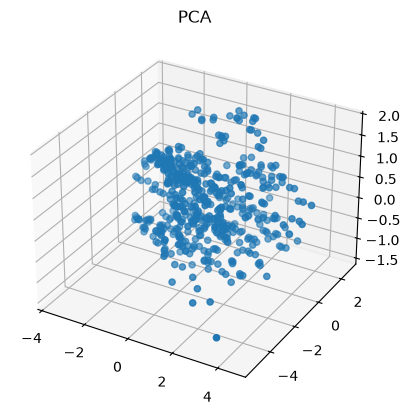

In [94]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_data[:, 0], pca_data[:, 1], pca_data[:, 2])
plt.title('PCA')

# **Clustering**

In [95]:
tsne = TSNE(n_components=3, random_state=42)
tsne_data = tsne.fit_transform(data)

## **K-Means**

In [96]:
cluster_range = range(1, 21)
inertias = []
for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, n_init='auto').fit(data)
    inertias.append(kmeans.inertia_)

In [97]:
kmeans = KMeans(n_clusters=5, n_init='auto').fit(data)

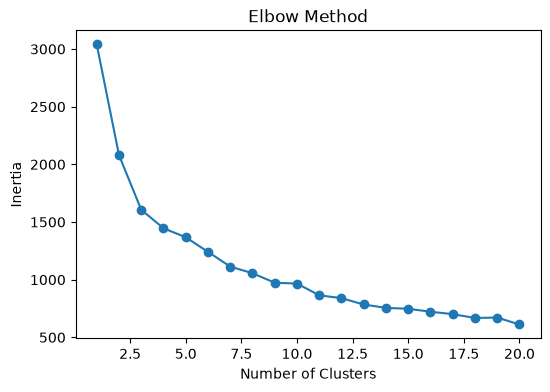

In [98]:
plt.figure(figsize=(6,4))
plt.plot(cluster_range, inertias, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Text(0.5, 0.92, 'K-Means Clusters (t-SNE)')

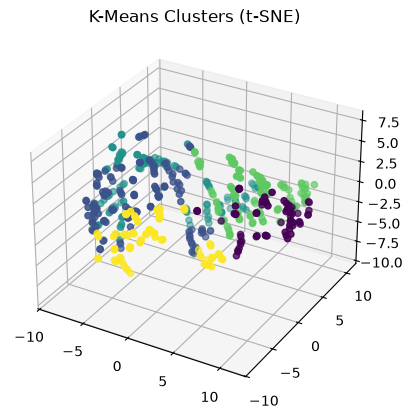

In [99]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(tsne_data[:, 0], tsne_data[:, 1], tsne_data[:, 2], c=kmeans.labels_)
plt.title('K-Means Clusters (t-SNE)')

## **DBSCAN**

In [100]:
dbscan = DBSCAN(eps=1).fit(data)

Text(0.5, 0.92, 'DBSCAN Clusters (t-SNE)')

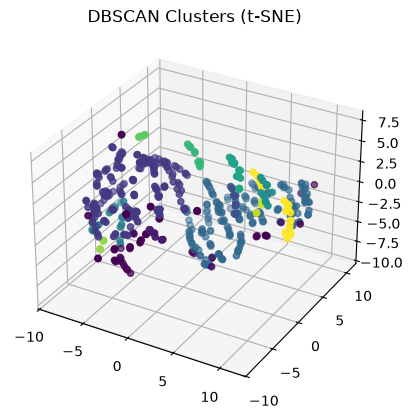

In [101]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(tsne_data[:, 0], tsne_data[:, 1], tsne_data[:, 2], c=dbscan.labels_)
plt.title('DBSCAN Clusters (t-SNE)')